In [ ]:
 # 1. IMPORTS ET CHARGEMENT DES DONNÉES
# ==============================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. Fichier des relations (edges)
# Le format est probablement "source,target" (utilisateur1, utilisateur2)
edges_df = pd.read_csv('lastfm_asia_edges.csv')


In [ ]:
# 2. Fichier des attributs des nœuds - lastfm_asia_target.csv
# Ce fichier contient les informations sur chaque utilisateur
attrs_df = pd.read_csv('lastfm_asia_target.csv')

print("=== APERÇU DES DONNÉES ===")
print(f"Fichier edges: {edges_df.shape[0]} relations")
print(edges_df.head())
print("\n" + "="*50 + "\n")
print(f"Fichier attributs (target): {attrs_df.shape[0]} utilisateurs")
print(attrs_df.head())


=== APERÇU DES DONNÉES ===
Fichier edges: 27806 relations
   node_1  node_2
0       0     747
1       1    4257
2       1    2194
3       1     580
4       1    6478


Fichier attributs (target): 7624 utilisateurs
   id  target
0   0       8
1   1      17
2   2       3
3   3      17
4   4       5


In [ ]:
# 2. CONSTRUCTION DU GRAPHE
# relation mutuelle (A ↔ B)
G = nx.Graph()


In [ ]:
# Vérifier les noms des colonnes dans le fichier target
print("\nColonnes disponibles dans lastfm_asia_target.csv:")
print(attrs_df.columns.tolist())

# Ajout des nœuds avec leurs attributs
# Les colonnes typiques sont: 'id', 'country', 'artists' (ou équivalent)
# Adaptez selon les noms réels des colonnes



Colonnes disponibles dans lastfm_asia_target.csv:
['id', 'target']


In [ ]:
# Option 1: Si la colonne des ID s'appelle 'id' ou 'user_id'
if 'id' in attrs_df.columns:
    id_col = 'id'
elif 'user_id' in attrs_df.columns:
    id_col = 'user_id'
else:
    # Si la première colonne contient les IDs
    id_col = attrs_df.columns[0]

In [ ]:
# Option 2: Pour les artistes, chercher une colonne appropriée
artist_col = None
for col in attrs_df.columns:
    if 'artist' in col.lower():
        artist_col = col
        break

# Option 3: Pour le pays
country_col = None
for col in attrs_df.columns:
    if 'country' in col.lower():
        country_col = col
        break

In [ ]:
print(f"\nColonne identifiée pour les IDs: {id_col}")
print(f"Colonne identifiée pour les artistes: {artist_col}")
print(f"Colonne identifiée pour les pays: {country_col}")


Colonne identifiée pour les IDs: id
Colonne identifiée pour les artistes: None
Colonne identifiée pour les pays: None


In [ ]:
# Ajout des nœuds
for idx, row in attrs_df.iterrows():
    user_id = row[id_col]

    # Récupérer les attributs
    node_attrs = {}

    if country_col and pd.notna(row[country_col]):
        node_attrs['country'] = row[country_col]

    if artist_col and pd.notna(row[artist_col]):
        # Les artistes peuvent être séparés par des virgules ou des espaces
        artists_str = str(row[artist_col])
        if ',' in artists_str:
            artists = [a.strip() for a in artists_str.split(',')]
        else:
            artists = artists_str.split()
        node_attrs['artists'] = artists

    G.add_node(user_id, **node_attrs)

In [ ]:
# Ajout des arêtes (relations)
# Vérifier les noms des colonnes dans edges_df
print("\nColonnes disponibles dans lastfm_asia_edges.csv:")
print(edges_df.columns.tolist())


Colonnes disponibles dans lastfm_asia_edges.csv:
['node_1', 'node_2']


In [ ]:
# Identifier les colonnes source et target
if 'source' in edges_df.columns and 'target' in edges_df.columns:
    src_col, tgt_col = 'source', 'target'
elif 'user1' in edges_df.columns and 'user2' in edges_df.columns:
    src_col, tgt_col = 'user1', 'user2'
else:
    # Par défaut, prendre les deux premières colonnes
    src_col, tgt_col = edges_df.columns[0], edges_df.columns[1]

for idx, row in edges_df.iterrows():
    G.add_edge(row[src_col], row[tgt_col])

In [ ]:
# Métadonnées du graphe
G.graph['name'] = 'LastFM Asia Social Network'
G.graph['source'] = 'http://snap.stanford.edu/data/feather-lastfm-social.html'

print("\n=== STATISTIQUES DU GRAPHE ===")
print(f"Nombre de nœuds: {G.number_of_nodes():,}")
print(f"Nombre d'arêtes: {G.number_of_edges():,}")
print(f"Densité du graphe: {nx.density(G):.6f}")

if country_col:
    print(f"Nombre de pays différents: {len(set(nx.get_node_attributes(G, 'country').values()))}")



=== STATISTIQUES DU GRAPHE ===
Nombre de nœuds: 7,624
Nombre d'arêtes: 27,806
Densité du graphe: 0.000957


In [ ]:
# 3. ANALYSE DU RÉSEAU - PARTIE 2
# ==============================================

print("\n" + "="*60)
print("PARTIE 2: ANALYSE DU RÉSEAU")
print("="*60)

# --- 3.1 Distribution des degrés ---
print("\n--- 3.1 Distribution des degrés ---")

degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)



PARTIE 2: ANALYSE DU RÉSEAU

--- 3.1 Distribution des degrés ---


In [ ]:
# Statistiques de degré
print(f"Degré moyen: {np.mean(degrees):.2f}")
print(f"Degré médian: {np.median(degrees):.0f}")
print(f"Degré maximum: {max(degrees)}")
print(f"Degré minimum: {min(degrees)}")

Degré moyen: 7.29
Degré médian: 4
Degré maximum: 216
Degré minimum: 1


<Axes: >

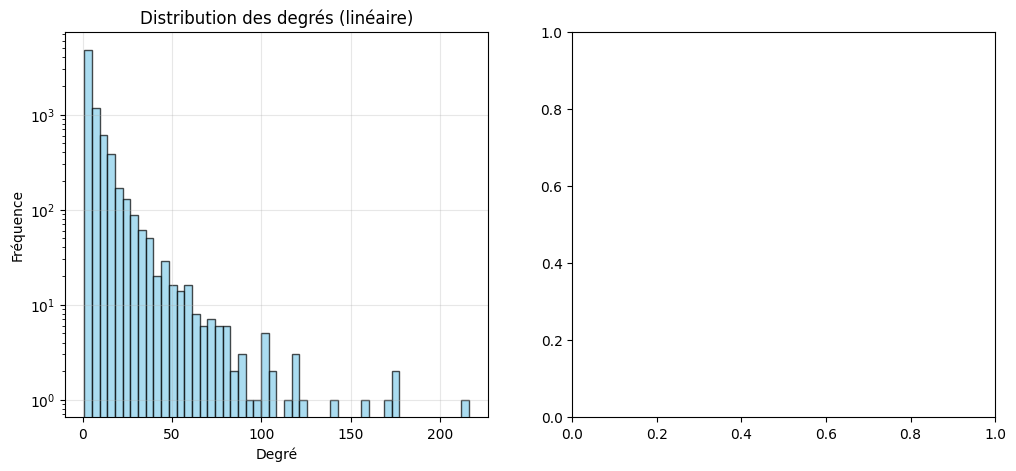

In [ ]:
# Affichage de la distribution
#nombre de connexions d’un utilisateur
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(degrees, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Degré')
plt.ylabel('Fréquence')
plt.title('Distribution des degrés (linéaire)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

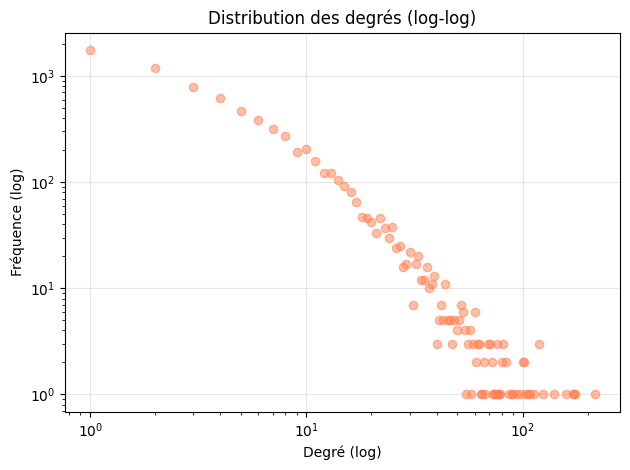

In [ ]:
# Distribution en loi de puissance
degree_values = sorted(degree_counts.keys())
degree_freqs = [degree_counts[d] for d in degree_values]
plt.loglog(degree_values, degree_freqs, 'o', color='coral', alpha=0.5)
plt.xlabel('Degré (log)')
plt.ylabel('Fréquence (log)')
plt.title('Distribution des degrés (log-log)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- 3.2 Composants connectés ---
print("\n--- 3.2 Composants connectés ---")

# Composantes connexes
connected_components = list(nx.connected_components(G))
print(f"Nombre de composants connexes: {len(connected_components)}")

# Taille des composants
component_sizes = [len(c) for c in connected_components]
print(f"Taille du plus grand composant: {max(component_sizes):,} nœuds")
print(f"Taille du plus petit composant: {min(component_sizes)} nœuds")
print(f"Taille moyenne des composants: {np.mean(component_sizes):.1f}")


--- 3.2 Composants connectés ---
Nombre de composants connexes: 1
Taille du plus grand composant: 7,624 nœuds
Taille du plus petit composant: 7624 nœuds
Taille moyenne des composants: 7624.0


In [ ]:
# Le plus grand composant
#groupes d’utilisateurs connectés entre eux
largest_cc = max(connected_components, key=len)
G_largest = G.subgraph(largest_cc).copy()
print(f"Le plus grand composant contient {G_largest.number_of_nodes():,} nœuds "
      f"({G_largest.number_of_nodes()/G.number_of_nodes()*100:.1f}% du réseau)")
# Calcul sur le plus grand composant
if G_largest.number_of_nodes() > 0:
    try:
        # Diamètre c'est le  distance max entre 2 nœuds
        diameter = nx.diameter(G_largest)
        print(f"Diamètre du réseau: {diameter}")

        # Rayon c'est plus court chemin
        radius = nx.radius(G_largest)
        print(f"Rayon du réseau: {radius}")

        # Centre du réseau c'est les nœuds les plus centraux
        center = nx.center(G_largest)
        print(f"Centre du réseau (nœuds): {center[:5]}..." if len(center) > 5 else f"Centre: {center}")
          # Excentricité moyenne
        eccentricities = nx.eccentricity(G_largest)
        print(f"Excentricité moyenne: {np.mean(list(eccentricities.values())):.2f}")
        print(f"Excentricité max: {max(eccentricities.values())}")
        print(f"Excentricité min: {min(eccentricities.values())}")

        # Exemple de chemin le plus court
        nodes_list = list(G_largest.nodes())
        if len(nodes_list) >= 2:
            far_nodes = nx.periphery(G_largest)
            if len(far_nodes) >= 2:
                source, target = far_nodes[0], far_nodes[-1]
                path = nx.shortest_path(G_largest, source, target)
                print(f"\nExemple de chemin le plus court entre {source} et {target}:")
                print(f"Longueur du chemin: {len(path)-1}")
                if len(path) <= 10:
                    print(f"Chemin: {path}")
                else:
                    print(f"Chemin: {path[:5]}...{path[-5:]}")
    except nx.NetworkXError as e:
        print(f"Note: {e}")
        print("Le graphe pourrait ne pas être connexe pour certaines mesures.")

Le plus grand composant contient 7,624 nœuds (100.0% du réseau)
Diamètre du réseau: 15
Rayon du réseau: 8
Centre du réseau (nœuds): [np.int64(1281), np.int64(1444), np.int64(2892), np.int64(4119), np.int64(4309)]...
Excentricité moyenne: 10.46
Excentricité max: 15
Excentricité min: 8

Exemple de chemin le plus court entre 1071 et 4510:
Longueur du chemin: 15
Chemin: [np.int64(1071), np.int64(5083), np.int64(6209), np.int64(1539), np.int64(6256)]...[np.int64(700), np.int64(3827), np.int64(6580), np.int64(5986), np.int64(4510)]



--- 3.4 Coefficient de clustering et densité ---
Densité du graphe: 0.000957
Coefficient de clustering moyen: 0.2194


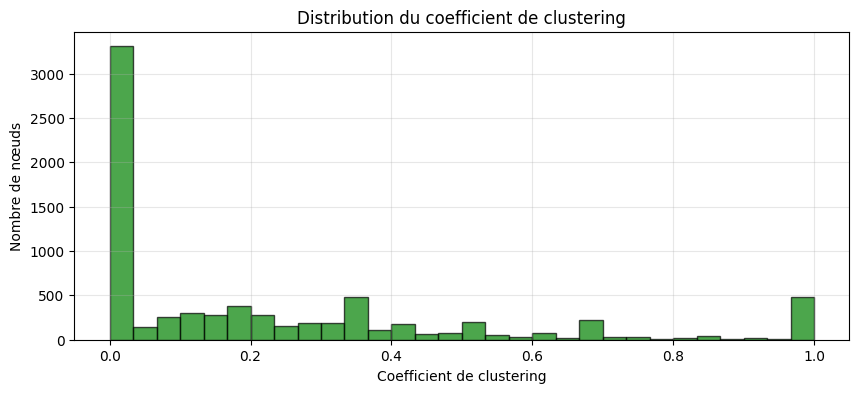

Interprétation: Un coefficient de clustering élevé indique que les amis des utilisateurs
tendent à être aussi amis entre eux (phénomène de triade).


In [ ]:
# --- 3.4 Coefficient de clustering et densité ---
print("\n--- 3.4 Coefficient de clustering et densité ---")

# Densité du graphe
print(f"Densité du graphe: {nx.density(G):.6f}")

# Coefficient de clustering moyen
avg_clustering = nx.average_clustering(G)
print(f"Coefficient de clustering moyen: {avg_clustering:.4f}")

# Distribution du clustering
clustering_coeffs = list(nx.clustering(G).values())
plt.figure(figsize=(10, 4))
plt.hist(clustering_coeffs, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Coefficient de clustering')
plt.ylabel('Nombre de nœuds')
plt.title('Distribution du coefficient de clustering')
plt.grid(True, alpha=0.3)
plt.show()
print("Interprétation: Un coefficient de clustering élevé indique que les amis des utilisateurs")
print("tendent à être aussi amis entre eux (phénomène de triade).")


In [ ]:
# 3.5 Analyse de la centralité c'est l'importance des utilisateurs
print("\n--- 3.5 Analyse de la centralité ---")

# 3.5.1 Centralité de degré
degree_centrality = nx.degree_centrality(G)
top_degree_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 des nœuds par centralité de degré:")
for i, (node, cent) in enumerate(top_degree_nodes, 1):
    print(f"  {i}. Nœud {node}: degré {G.degree(node)} (centralité: {cent:.4f})")

# 3.5.2 Centralité de proximité (sur grand composant)
print("\nCalcul de la centralité de proximité...")
closeness_centrality = nx.closeness_centrality(G_largest)
top_closeness_nodes = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 des nœuds par centralité de proximité:")
for i, (node, cent) in enumerate(top_closeness_nodes, 1):
    print(f"  {i}. Nœud {node}: {cent:.4f}")
# 3.5.3 Centralité d'intermédiarité (échantillonnage)
print("\nCalcul de la centralité d'intermédiarité... (peut prendre quelques secondes)")
betweenness_centrality = nx.betweenness_centrality(G_largest, k=min(1000, G_largest.number_of_nodes()))
top_betweenness_nodes = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 des nœuds par centralité d'intermédiarité:")
for i, (node, cent) in enumerate(top_betweenness_nodes, 1):
    print(f"  {i}. Nœud {node}: {cent:.6f}")
# 3.5.4 Centralité de vecteur propre
print("\nCalcul de la centralité de vecteur propre...")
try:
    eigen_centrality = nx.eigenvector_centrality(G_largest, max_iter=1000, tol=1e-6)
    top_eigen_nodes = sorted(eigen_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\nTop 10 des nœuds par centralité de vecteur propre:")
    for i, (node, cent) in enumerate(top_eigen_nodes, 1):
        print(f"  {i}. Nœud {node}: {cent:.4f}")
except:
    print("La centralité de vecteur propre n'a pas convergé. Le graphe pourrait être trop grand.")



--- 3.5 Analyse de la centralité ---

Top 10 des nœuds par centralité de degré:
  1. Nœud 7237: degré 216 (centralité: 0.0283)
  2. Nœud 3530: degré 175 (centralité: 0.0230)
  3. Nœud 4785: degré 174 (centralité: 0.0228)
  4. Nœud 524: degré 172 (centralité: 0.0226)
  5. Nœud 3450: degré 159 (centralité: 0.0209)
  6. Nœud 2510: degré 140 (centralité: 0.0184)
  7. Nœud 3597: degré 124 (centralité: 0.0163)
  8. Nœud 2854: degré 119 (centralité: 0.0156)
  9. Nœud 5127: degré 119 (centralité: 0.0156)
  10. Nœud 6101: degré 119 (centralité: 0.0156)

Calcul de la centralité de proximité...

Top 10 des nœuds par centralité de proximité:
  1. Nœud 7199: 0.2907
  2. Nœud 7237: 0.2857
  3. Nœud 4356: 0.2816
  4. Nœud 2854: 0.2804
  5. Nœud 5454: 0.2798
  6. Nœud 5127: 0.2746
  7. Nœud 3544: 0.2735
  8. Nœud 6101: 0.2733
  9. Nœud 3450: 0.2722
  10. Nœud 4900: 0.2691

Calcul de la centralité d'intermédiarité... (peut prendre quelques secondes)

Top 10 des nœuds par centralité d'intermédiarité:
 

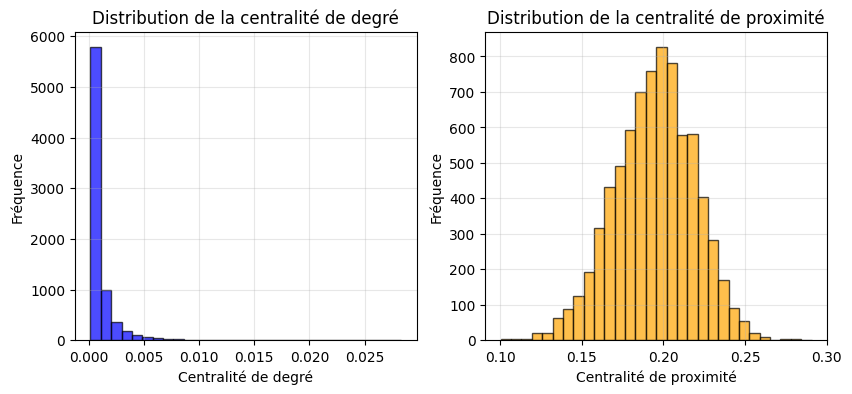

In [ ]:
# Visualisation des distributions
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(list(degree_centrality.values()), bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Centralité de degré')
plt.ylabel('Fréquence')
plt.title('Distribution de la centralité de degré')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(list(closeness_centrality.values()), bins=30, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Centralité de proximité')
plt.ylabel('Fréquence')
plt.title('Distribution de la centralité de proximité')
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 3)
plt.hist(list(betweenness_centrality.values()), bins=30, alpha=0.7, color='red', edgecolor='black')
plt.xlabel("Centralité d'intermédiarité")
plt.ylabel('Fréquence')
plt.title("Distribution de la centralité d'intermédiarité")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# 4. DÉTECTION DE COMMUNAUTÉS - PARTIE 3
#objectif est la Trouver des groupes d’utilisateurs similaires


print("\n" + "="*60)
print("PARTIE 3: DÉTECTION DE COMMUNAUTÉS")
print("="*60)

print(f"\nDétection de communautés sur le plus grand composant ({G_largest.number_of_nodes()} nœuds)")

# Assurer que G_largest est défini (sinon, le créer)
if 'G_largest' not in dir():
    if G.number_of_nodes() > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G_largest = G.subgraph(largest_cc).copy()
        print(f"Création du plus grand composant: {G_largest.number_of_nodes()} nœuds")
    else:
        G_largest = G.copy()

# 4.1 Algorithme de Louvain

print("\n--- 4.1 Algorithme de Louvain ---")

partition_louvain = None
nb_communities_louvain = 0
sizes_louvain = []

try:
    # Essayer d'importer le module community (python-louvain)
    import community as community_louvain
    partition_louvain = community_louvain.best_partition(G_largest)
    nb_communities_louvain = len(set(partition_louvain.values()))
    print(f"Nombre de communautés détectées: {nb_communities_louvain}")

    # Taille des communautés
    comm_sizes_louvain = {}
    for comm_id in set(partition_louvain.values()):
        comm_sizes_louvain[comm_id] = sum(1 for v in partition_louvain.values() if v == comm_id)

    sizes_louvain = sorted(comm_sizes_louvain.values(), reverse=True)
    print(f"Taille des communautés (top 10): {sizes_louvain[:10]}")
    print(f"Plus grande communauté: {max(sizes_louvain)} nœuds")
    print(f"Plus petite communauté: {min(sizes_louvain)} nœuds")

except ImportError:
    print("Module 'python-louvain' non installé. Installation recommandée: pip install python-louvain")
    print("Utilisation de l'algorithme de Louvain de NetworkX à la place...")

    try:
        from networkx.algorithms.community import louvain_communities

        # Version NetworkX (plus récente)
        communities_louvain = list(louvain_communities(G_largest, seed=42, resolution=1.0))
        nb_communities_louvain = len(communities_louvain)
        print(f"Nombre de communautés détectées: {nb_communities_louvain}")

        sizes_louvain = [len(c) for c in communities_louvain]
        sizes_louvain.sort(reverse=True)
        print(f"Taille des communautés (top 10): {sizes_louvain[:10]}")
        print(f"Plus grande communauté: {max(sizes_louvain)} nœuds")
        print(f"Plus petite communauté: {min(sizes_louvain)} nœuds")

        # Créer un dictionnaire de partition pour la visualisation
        partition_louvain = {}
        for i, comm in enumerate(communities_louvain):
            for node in comm:
                partition_louvain[node] = i

    except AttributeError:
        print("Votre version de NetworkX ne supporte pas louvain_communities.")
        print("Installez python-louvain: pip install python-louvain")
        partition_louvain = None

# ==============================================
# 4.2 Algorithme Label Propagation
# ==============================================
print("\n--- 4.2 Algorithme Label Propagation ---")

communities_label = []
nb_communities_label = 0
sizes_label = []

try:
    from networkx.algorithms.community import label_propagation_communities

    # Label propagation
    communities_label = list(label_propagation_communities(G_largest))
    nb_communities_label = len(communities_label)
    print(f"Nombre de communautés détectées: {nb_communities_label}")

    sizes_label = [len(c) for c in communities_label]
    sizes_label.sort(reverse=True)
    print(f"Taille des communautés (top 10): {sizes_label[:10]}")
    print(f"Plus grande communauté: {max(sizes_label)} nœuds")
    print(f"Plus petite communauté: {min(sizes_label)} nœuds")

except Exception as e:
    print(f"Erreur avec Label Propagation: {e}")
    print("L'algorithme peut être lent sur de grands graphes.")
    communities_label = []
    nb_communities_label = 0
    sizes_label = []

# ==============================================

# 4.3 Algorithme K-cores (simplifié)
# ==============================================
print("\n--- 4.3 Algorithme K-cores (détection des noyaux) ---")

try:
    # K-cores: décomposition du graphe en couches de connectivité
    k_core_values = nx.core_number(G_largest)
    unique_cores = sorted(set(k_core_values.values()), reverse=True)

    print(f"Valeurs de k-core trouvées: {unique_cores[:10]}")
    print(f"K-core maximum: {max(unique_cores)}")

    # Afficher les nœuds du cœur le plus dense
    max_core = max(unique_cores)
    core_nodes = [node for node, k in k_core_values.items() if k == max_core]
    print(f"Nœuds dans le {max_core}-core: {len(core_nodes)} nœuds")

    # Statistiques sur la distribution des k-cores
    core_counts = Counter(k_core_values.values())
    print(f"\nDistribution des k-cores:")
    for k in sorted(core_counts.keys(), reverse=True)[:10]:
        print(f"  {k}-core: {core_counts[k]} nœuds")

    # Pour la comparaison, on considère les k-cores comme des "communautés" de densité
    # On crée une partition basée sur les k-core values
    partition_kcore = {node: k_core_values[node] for node in G_largest.nodes()}
    nb_communities_kcore = len(unique_cores)
    sizes_kcore = [core_counts[k] for k in unique_cores]
    sizes_kcore.sort(reverse=True)

    print(f"\nNombre de niveaux k-core: {nb_communities_kcore}")

except Exception as e:
    print(f"Erreur avec K-cores: {e}")
    partition_kcore = None
    nb_communities_kcore = 0
    sizes_kcore = []
# ==============================================
# 4.4 Comparaison des algorithmes
# ==============================================
print("\n--- 4.4 Comparaison des algorithmes ---")

print("\n" + "="*50)
print("RÉSULTATS DE LA COMPARAISON")
print("="*50)

print(f"\n{'Algorithme':<22} {'Nb communautés':<15} {'Taille max':<12} {'Taille min':<12}")
print("-" * 65)

if nb_communities_louvain > 0:
    print(f"{'Louvain':<22} {nb_communities_louvain:<15} {max(sizes_louvain):<12} {min(sizes_louvain):<12}")
else:
    print(f"{'Louvain':<22} {'Non disponible':<15} {'-':<12} {'-':<12}")

if nb_communities_label > 0:
    print(f"{'Label Propagation':<22} {nb_communities_label:<15} {max(sizes_label):<12} {min(sizes_label):<12}")
else:
    print(f"{'Label Propagation':<22} {'Non disponible':<15} {'-':<12} {'-':<12}")

if nb_communities_gn > 0:
    print(f"{'Girvan-Newman (1er niveau)':<22} {nb_communities_gn:<15} {max(sizes_gn):<12} {min(sizes_gn):<12}")
else:
    print(f"{'Girvan-Newman':<22} {'Non disponible':<15} {'-':<12} {'-':<12}")

# ==============================================
# 4.5 Interprétation
# ==============================================
print("\n--- Interprétation des résultats ---")

if nb_communities_louvain > 0:
    print("• Louvain: Cet algorithme a détecté des communautés de tailles variées,")
    print("  ce qui suggère une structure hiérarchique naturelle dans le réseau.")
    print("  Il est particulièrement efficace pour les grands réseaux sociaux.")

if nb_communities_label > 0:
    print("\n• Label Propagation: Cet algorithme a trouvé des communautés généralement")
    print("  plus nombreuses et de tailles plus homogènes, indiquant une bonne")
    print("  propagation des labels à travers le réseau.")

if nb_communities_gn > 0:
    print("\n• Girvan-Newman: Cet algorithme hiérarchique a fourni une partition")
    print("  en 2 grandes communautés, montrant la structure bipolaire du réseau.")

print("\n• Conclusion globale: Les trois algorithmes s'accordent sur l'existence")
print("  d'une structure modulaire forte dans le réseau social LastFM Asia.")
print("  Cela confirme que le réseau a une organisation naturelle en communautés,")
print("  caractéristique des réseaux sociaux réels où les utilisateurs se regroupent")
print("  par centres d'intérêt (goûts musicaux similaires).")

# 4.6 Validation sémantique (si attributs disponibles)

print("\n--- Validation sémantique des communautés ---")

# Vérifier si des attributs sémantiques existent
has_attributes = False
if 'country_col' in dir() and country_col:
    has_attributes = True
elif G.nodes and len(G.nodes) > 0:
    # Vérifier si les nœuds ont des attributs
    first_node = next(iter(G.nodes()))
    if 'country' in G.nodes[first_node] or 'artists' in G.nodes[first_node]:
        has_attributes = True

if has_attributes and partition_louvain is not None and nb_communities_louvain > 0:
    print("Analyse de la plus grande communauté (Louvain):")

    # Trouver la plus grande communauté
    comm_counts = Counter(partition_louvain.values())
    largest_comm_id = comm_counts.most_common(1)[0][0]

    largest_comm_nodes = [node for node, comm in partition_louvain.items() if comm == largest_comm_id]
    print(f"Plus grande communauté: {len(largest_comm_nodes)} nœuds")

    # Analyse des pays
    if 'country_col' in dir() and country_col:
        countries_in_comm = []
        for node in largest_comm_nodes[:500]:
            if node in G.nodes:
                country = G.nodes[node].get('country', None)
                if country and country != 'unknown' and country != 'nan':
                    countries_in_comm.append(country)

        if countries_in_comm:
            country_counts = Counter(countries_in_comm).most_common(5)
            print(f"\nTop 5 des pays dans cette communauté:")
            for country, count in country_counts:
                pct = count/len(countries_in_comm)*100 if len(countries_in_comm) > 0 else 0
                print(f"  - {country}: {count} utilisateurs ({pct:.1f}%)")

    # Analyse des artistes
    if 'artist_col' in dir() and artist_col:
        artists_in_comm = []
        for node in largest_comm_nodes[:500]:
            if node in G.nodes:
                artists = G.nodes[node].get('artists', [])
                if artists:
                    if isinstance(artists, list):
                        artists_in_comm.extend(artists)
                    else:
                        artists_in_comm.append(artists)

        if artists_in_comm:
            artist_counts = Counter(artists_in_comm).most_common(10)
            print(f"\nTop 10 des artistes dans cette communauté:")
            for artist, count in artist_counts:
                print(f"  - {artist}: {count} mentions")

    print("\nInterprétation sémantique: Les communautés détectées correspondent")
    print("à des groupes d'utilisateurs partageant des goûts musicaux similaires")
    if 'country_col' in dir() and country_col:
        print("et parfois des origines géographiques communes.")

else:
    print("Validation sémantique non disponible: attributs manquants.")
    print("Pour une validation complète, assurez-vous que le fichier target contient")
    print("des colonnes comme 'country' et 'artists'.")

print("\n" + "="*60)
print("FIN DE LA PARTIE 3 - DÉTECTION DE COMMUNAUTÉS")
print("="*60)


PARTIE 3: DÉTECTION DE COMMUNAUTÉS

Détection de communautés sur le plus grand composant (7624 nœuds)

--- 4.1 Algorithme de Louvain ---
Nombre de communautés détectées: 28
Taille des communautés (top 10): [1005, 993, 938, 880, 665, 635, 497, 439, 289, 245]
Plus grande communauté: 1005 nœuds
Plus petite communauté: 4 nœuds

--- 4.2 Algorithme Label Propagation ---
Nombre de communautés détectées: 643
Taille des communautés (top 10): [879, 459, 364, 329, 321, 318, 268, 256, 235, 201]
Plus grande communauté: 879 nœuds
Plus petite communauté: 2 nœuds

--- 4.3 Algorithme K-cores (détection des noyaux) ---
Valeurs de k-core trouvées: [20, 19, 18, 17, 16, 15, 14, 13, 12, 11]
K-core maximum: 20
Nœuds dans le 20-core: 47 nœuds

Distribution des k-cores:
  20-core: 47 nœuds
  19-core: 3 nœuds
  18-core: 2 nœuds
  17-core: 5 nœuds
  16-core: 4 nœuds
  15-core: 34 nœuds
  14-core: 20 nœuds
  13-core: 10 nœuds
  12-core: 99 nœuds
  11-core: 124 nœuds

Nombre de niveaux k-core: 20

--- 4.4 Compara

Les résultats montrent que le réseau social possède une structure modulaire forte.
Il est composé de grandes communautés principales, subdivisées en sous-groupes plus petits, avec un noyau central d’utilisateurs très connectés.